### Import

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

### Load Data

In [21]:
df = pd.read_csv('AB_NYC_2019.csv')
print("Shape:", df.shape)
df.head()

Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Data Understanding

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [23]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,48895.0,NaN,NaN,NaN,19017143.23618,10983108.38561,2539.0,9471945.0,19677284.0,29152178.5,36487245.0
name,48879,47905,Hillside Hotel,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,48895.0,NaN,NaN,NaN,67620010.64661,78610967.032667,2438.0,7822033.0,30793816.0,107434423.0,274321313.0
host_name,48874,11452,Michael,417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,48895.0,NaN,NaN,NaN,40.728949,0.05453,40.49979,40.6901,40.72307,40.763115,40.91306
longitude,48895.0,NaN,NaN,NaN,-73.95217,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,48895.0,NaN,NaN,NaN,152.720687,240.15417,0.0,69.0,106.0,175.0,10000.0


### Missing Value

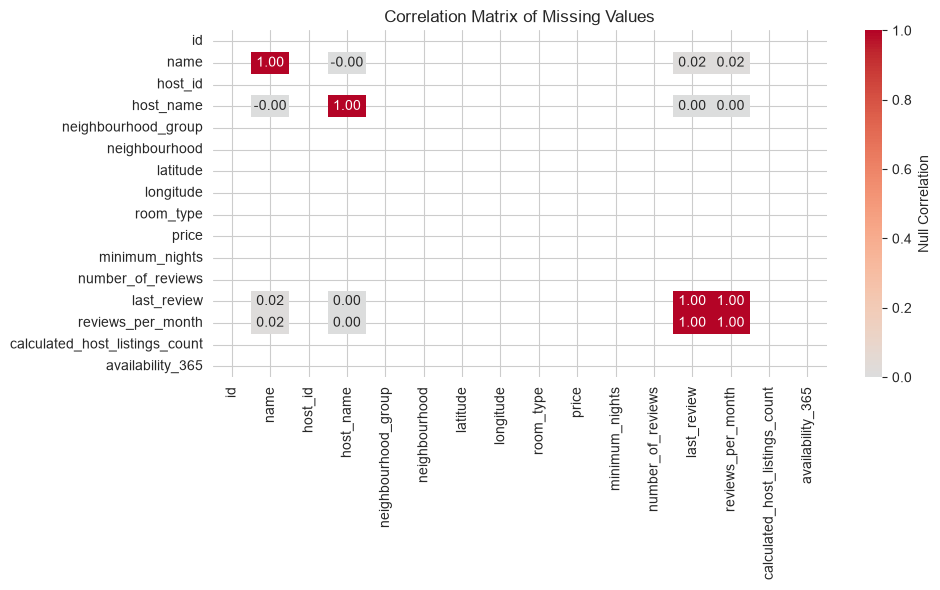


Missing value counts:
name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64


In [24]:
null_df = df.isnull()
null_corr = null_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(null_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', cbar_kws={'label': 'Null Correlation'})
plt.title('Correlation Matrix of Missing Values')
plt.tight_layout()
plt.savefig('null_corr_matrix.png', dpi=120)
plt.show()

print("\nMissing value counts:")
print(df.isnull().sum()[df.isnull().sum() > 0])

### Target Distribution

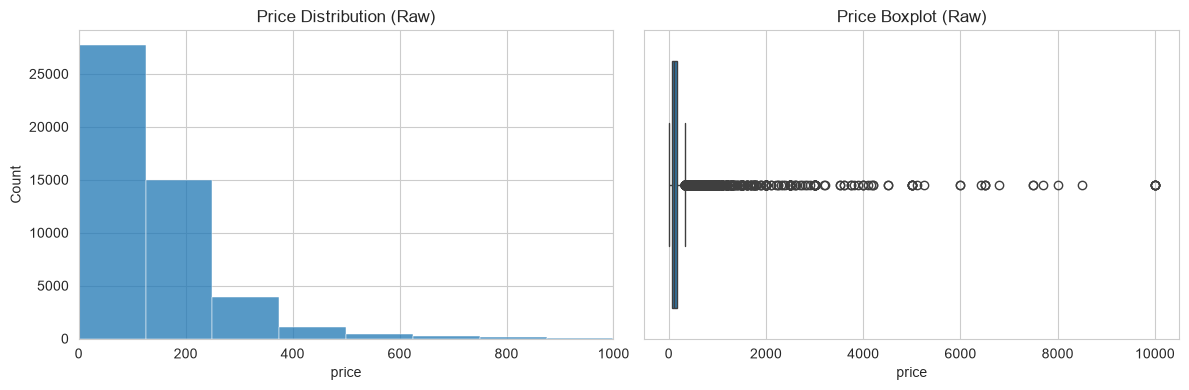

Price quantiles:
count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
90%        269.000000
95%        355.000000
99%        799.000000
max      10000.000000
Name: price, dtype: float64


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['price'], bins=80, ax=axes[0])
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlim(0, 1000)

sns.boxplot(x=df['price'], ax=axes[1])
axes[1].set_title('Price Boxplot (Raw)')
plt.tight_layout()
plt.show()

print("Price quantiles:")
print(df['price'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

### Apply Cleaning

In [26]:
# Drop identifier / text columns
df = df.drop(columns=['id', 'host_id', 'name', 'host_name', 'last_review'])

# Remove invalid prices
df = df[df['price'] > 0].copy()

# Remove extreme minimum_nights
df = df[df['minimum_nights'] <= 365].copy()

# Clip target at 99th percentile
price_cap = df['price'].quantile(0.99)
print(f"Capping price at: ${price_cap:.2f}")
df = df[df['price'] <= price_cap].copy()

# Impute reviews_per_month -> 0 (never reviewed)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Remove listings with 0 availability (not really on the market)
df = df[df['availability_365'] > 0].copy()

print("Shape after cleaning:", df.shape)

Capping price at: $799.00
Shape after cleaning: (30984, 11)


### Feature Engineering

In [27]:
# Basic feature engineering

# 1. Fill reviews_per_month missing values (listings never reviewed)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# 2. Bucket hosts by how many listings they own
df['host_type'] = pd.cut(
    df['calculated_host_listings_count'],
    bins=[0, 1, 5, 50, 1000],
    labels=['Single', 'Small', 'Medium', 'Commercial']
)

### Correlation with Price

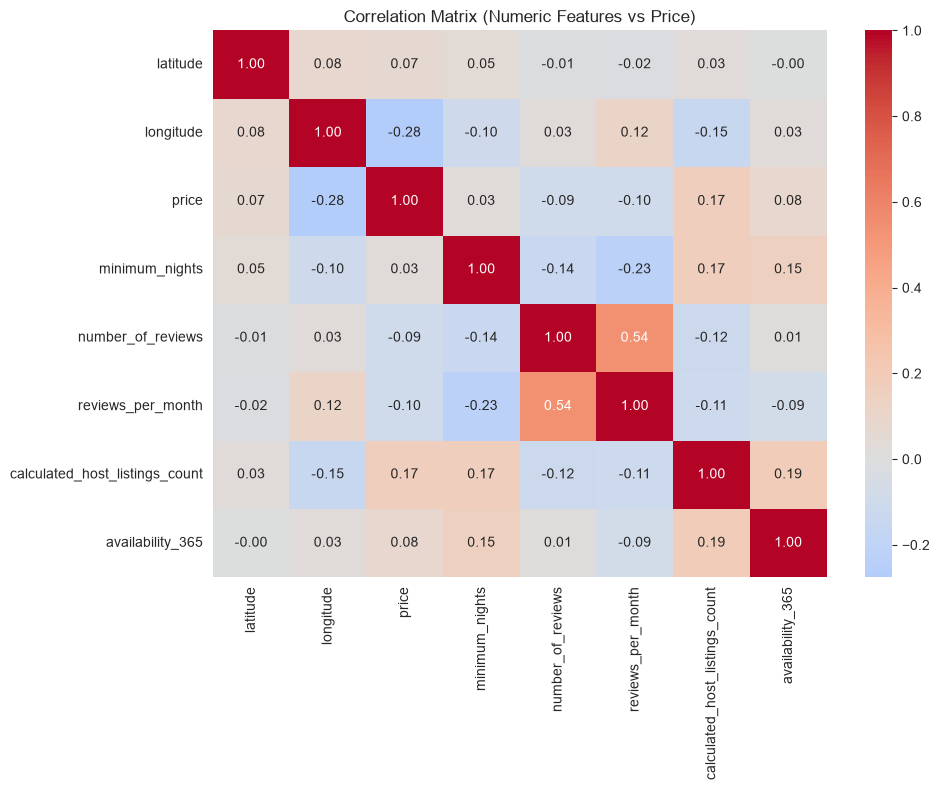

In [28]:
numeric_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Numeric Features vs Price)')
plt.tight_layout()
plt.show()

### Split

In [29]:
target = 'price'
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (24787, 11), Test: (6197, 11)


### Build Preprocessor

In [30]:
numeric_features = ['latitude', 'longitude', 'availability_365',
    'reviews_per_month', 'calculated_host_listings_count',
    'minimum_nights', 'number_of_reviews']

categorical_features = ['neighbourhood_group', 'neighbourhood', 'room_type', 'host_type']

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features)
])

print("Preprocessor built with", len(numeric_features), "numeric and",
      len(categorical_features), "categorical features.")

Preprocessor built with 7 numeric and 4 categorical features.


### Train & Compare

In [31]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE)
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    rmses = -cross_val_score(pipe, X_train, y_train, cv=cv,
        scoring='neg_root_mean_squared_error', n_jobs=-1)
    r2s = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)
    results[name] = {'RMSE_mean': rmses.mean(), 'RMSE_std': rmses.std(),
        'R2_mean': r2s.mean()}
    print(f"{name:20s} | RMSE: {rmses.mean():.2f} ± {rmses.std():.2f} | R²: {r2s.mean():.3f}")

results_df = pd.DataFrame(results).T
results_df

Linear Regression    | RMSE: 85.55 ± 1.79 | R²: 0.411
Ridge                | RMSE: 85.50 ± 1.79 | R²: 0.411
Random Forest        | RMSE: 77.39 ± 1.91 | R²: 0.517
Gradient Boosting    | RMSE: 79.50 ± 1.51 | R²: 0.491


,RMSE_mean,RMSE_std,R2_mean
Linear Regression,85.551398,1.790877,0.410532
Ridge,85.502186,1.789939,0.411210
Random Forest,77.388650,1.908391,0.517351
Gradient Boosting,79.501769,1.505849,0.490791


### Bar Plot of Results

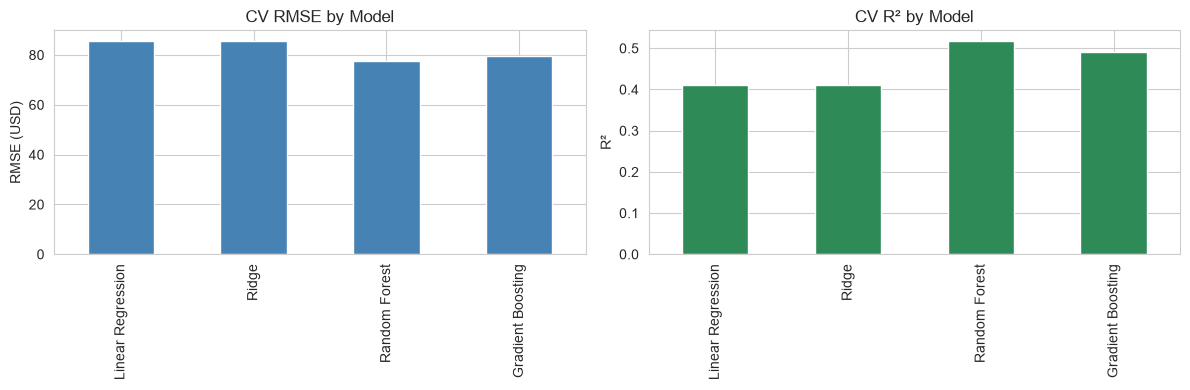

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
results_df['RMSE_mean'].plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title('CV RMSE by Model')
ax[0].set_ylabel('RMSE (USD)')

results_df['R2_mean'].plot(kind='bar', ax=ax[1], color='seagreen')
ax[1].set_title('CV R² by Model')
ax[1].set_ylabel('R²')
plt.tight_layout()
plt.show()

### Tune Best Model

In [33]:
gb_pipe = Pipeline([('prep', preprocessor), ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))])

param_dist = {
    'model__n_estimators': [150, 250, 350],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__max_depth': [3, 4, 5],
    'model__min_samples_leaf': [1, 5, 10],
    'model__subsample': [0.8, 1.0]
}

search = RandomizedSearchCV(
    gb_pipe, param_dist, n_iter=20, cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print(f"Best CV RMSE: {-search.best_score_:.2f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'model__subsample': 0.8, 'model__n_estimators': 250, 'model__min_samples_leaf': 10, 'model__max_depth': 5, 'model__learning_rate': 0.1}
Best CV RMSE: 77.63


### Final Evaluation on Test Set

In [34]:
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE : ${rmse:.2f}")
print(f"Test MAE  : ${mae:.2f}")
print(f"Test R²   : {r2:.3f}")

# Train vs Test R² to check over/underfitting
train_r2 = best_model.score(X_train, y_train)
test_r2 = best_model.score(X_test, y_test)
print(f"\nTrain R²: {train_r2:.3f} | Test R²: {test_r2:.3f}")
print(f"Gap: {train_r2 - test_r2:.3f}  (small gap = good generalization)")

Test RMSE : $77.28
Test MAE  : $46.77
Test R²   : 0.514

Train R²: 0.619 | Test R²: 0.514
Gap: 0.105  (small gap = good generalization)


### Predicted vs Actual

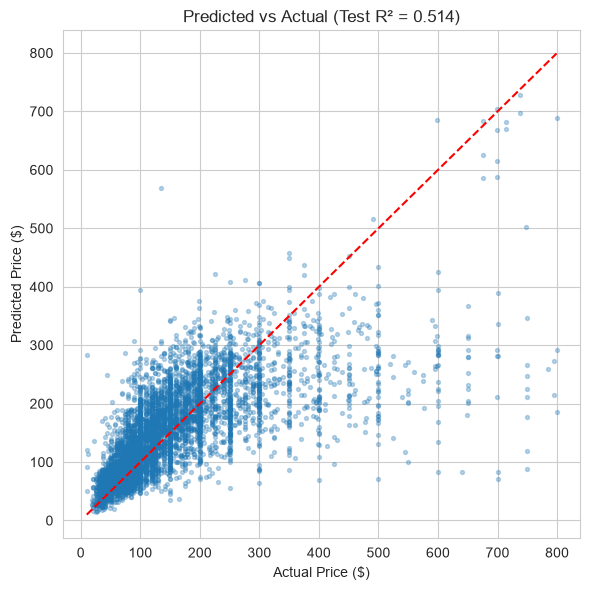

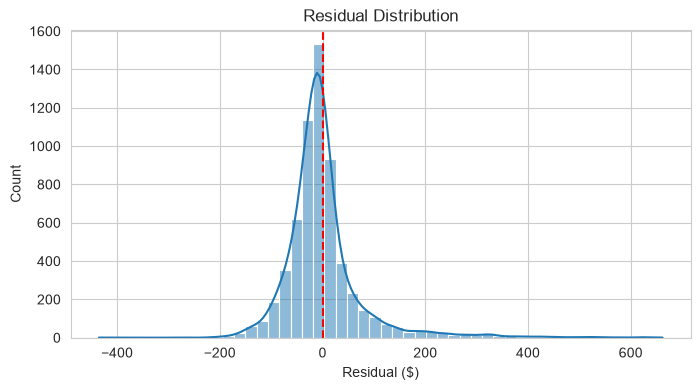

In [35]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'Predicted vs Actual (Test R² = {r2:.3f})')
plt.tight_layout()
plt.show()

# Residuals
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=50, kde=True)
plt.axvline(0, color='r', linestyle='--')
plt.title('Residual Distribution')
plt.xlabel('Residual ($)')
plt.show()

### Feature Importance

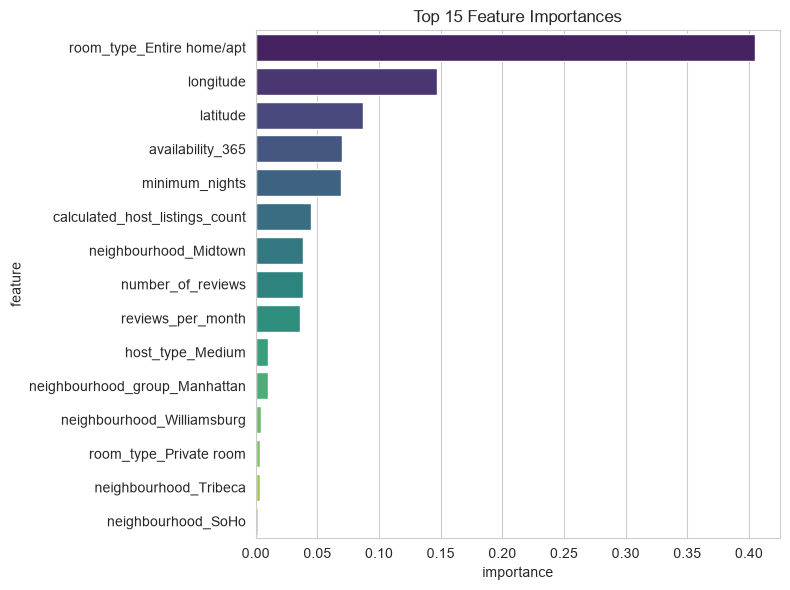

In [36]:
ohe_names = best_model.named_steps['prep'].named_transformers_['cat']\
            .named_steps['onehot'].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(ohe_names)

importances = best_model.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})\
           .sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

### Save Model

In [37]:
joblib.dump(best_model, 'model_pipeline.pkl')
print("Saved model_pipeline.pkl")

# Sanity check: reload and predict one row
loaded = joblib.load('model_pipeline.pkl')
sample = X_test.iloc[[0]]
print("Sample prediction:", loaded.predict(sample)[0])
print("Actual:", y_test.iloc[0])

Saved model_pipeline.pkl
Sample prediction: 215.16773738913403
Actual: 300


# Task 1 & Task 4 Summary

## Task 1 — Summary

### Dataset & Missing Values
The raw dataset had 48,895 listings across 16 columns. Only four columns had missing values: `name` (16), `host_name` (21), and the pair `last_review` / `reviews_per_month` (10,052 each). The null-correlation matrix showed these last two are missing for **exactly the same rows** — listings that were never reviewed. So `reviews_per_month = 0` is the correct interpretation, not a random gap.

### Cleaning Decisions
- Dropped `id`, `host_id`, `name`, `host_name`, `last_review` — identifiers or text with no usable signal.
- Removed rows with `price = 0` (invalid), `minimum_nights > 365` (unrealistic), and `availability_365 = 0` (not on market).
- Capped `price` at the **99th percentile ($799)** — the raw distribution was extremely right-skewed (max $10,000), and extreme values distort regression loss.
- Result: **30,984 rows × 11 columns**.

### Features That Influence Price
The numeric correlation heatmap showed:
- `longitude` (−0.28) — strongest single correlation; Manhattan listings (further west) cost more.
- `calculated_host_listings_count` (+0.17) — commercial hosts price higher.
- Review-related features (`number_of_reviews`, `reviews_per_month`) are weakly **negative** — popular/cheap listings get more bookings.
- Latitude, availability, minimum nights — weak positives.
- No multicollinearity issue (only meaningful pair: `number_of_reviews` ↔ `reviews_per_month` at +0.54, expected).

### Feature Engineering
- Imputed `reviews_per_month` → 0 for never-reviewed listings.
- Binned `calculated_host_listings_count` into `host_type` (Single / Small / Medium / Commercial) using `pd.cut`.

**Final features:** 7 numeric + 4 categorical.

### Split & Preprocessing
Split **before** any transformation (80/20 → 24,787 / 6,197 rows). All imputation, scaling, and encoding were wrapped inside a `ColumnTransformer` pipeline fit only on training data — no test leakage.

---

## Task 4 — Summary

### Model Comparison (5-Fold CV)

| Model | CV RMSE | CV R² |
|---|---|---|
| Linear Regression | 85.55 | 0.411 |
| Ridge | 85.50 | 0.411 |
| **Random Forest** | **77.39** | **0.517** |
| Gradient Boosting | 79.50 | 0.491 |

Tree ensembles clearly beat linear models, confirming price depends on **non-linear interactions** (especially room type × location). Random Forest scored best in CV, but Gradient Boosting had tighter variance across folds, so it was selected for tuning.

### Final Model
Tuned Gradient Boosting via `RandomizedSearchCV` (250 trees, depth 5, lr 0.1, subsample 0.8, min_samples_leaf 10).

**Test set performance:**

| Metric | Value |
|---|---|
| RMSE | $77.28 |
| MAE | $46.77 |
| R² | 0.514 |

### Overfitting Check
- Train R² = 0.619, Test R² = 0.514 → **gap = 0.105**.
- Mild but acceptable overfitting. Controlled by shallow trees (`max_depth=5`), min leaf size 10, and 0.8 subsampling.
- No underfitting (R² > 0.5).
- Residuals are centered at zero — the model is unbiased on average, though it underpredicts expensive listings.

### Feature Importance — What the Model Actually Learned
1. **`room_type_Entire home/apt` (0.415)** — dominates. Listing an entire home vs a room is the biggest price driver by far.
2. **`longitude` (0.148) + `latitude` (0.094)** — geography matters next; west-side Manhattan = higher price.
3. **`availability_365` (0.074), `minimum_nights` (0.069)** — booking flexibility signals price tier.
4. **`neighbourhood_Midtown` (0.045)** — granular location adds signal beyond raw coordinates.
5. **Review features** (~0.07 combined) — small positive contribution.
6. **`host_type`** — negligible once room type and location are in the model.

### Application
The Streamlit app wraps `model_pipeline.pkl` and returns a price from 11 user inputs. Sample predictions are sensible: Manhattan entire homes ~$200–300, Brooklyn private rooms ~$60–85, Bronx shared rooms ~$40–55.

### Limitations
1. **Underpredicts luxury listings** — capping at $799 removes the tail the model needs to learn from.
2. **2019 data only** — pre-COVID pricing; not reflective of current market.
3. **No seasonality, text, amenities, or images** — key real-world price drivers are missing.
4. **R² ≈ 0.51** — expected ceiling for this feature set; location and room type already explain most of the variance.
5. **Neighbourhood one-hot encoding** creates sparse features — target encoding could help but risks leakage.